In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [6]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df.drop(columns = ["RowNumber" , "CustomerId" , "Surname"] , inplace = True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df = pd.get_dummies(df, columns = ["Geography" , "Gender"] , drop_first = True)

In [11]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [12]:
x= df.drop(columns = ["Exited"])
y = df.Exited
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = .2 , random_state = 1)

In [13]:
x_train.shape

(8000, 11)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [15]:
x_train_scaled[1]

array([-0.25150912, -0.94449979, -0.35520275,  0.46984886,  0.80225696,
       -1.55337352, -1.02327069, -1.02548708, -0.58312392, -0.57273139,
       -1.09278791])

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [30]:
model = Sequential()

model.add(Dense(11 , activation = "relu" , input_dim = 11))
model.add(Dense(11 , activation = "relu"))
model.add(Dense(1 , activation = "sigmoid"))

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                132       
                                                                 
 dense_1 (Dense)             (None, 11)                132       
                                                                 
 dense_2 (Dense)             (None, 1)                 12        
                                                                 
Total params: 276 (1.08 KB)
Trainable params: 276 (1.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [31]:
model.compile(loss = "binary_crossentropy" , optimizer = "adam", metrics = "accuracy")

In [32]:
history = model.fit(x_train_scaled , y_train , epochs=100 , validation_split = 0.2)

Epoch 1/100
200/200 [==============================] - 2s 4ms/step - loss: 0.5132 - accuracy: 0.7852 - val_loss: 0.4744 - val_accuracy: 0.8075
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4489 - accuracy: 0.8175 - val_loss: 0.4462 - val_accuracy: 0.8112
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4305 - accuracy: 0.8219 - val_loss: 0.4328 - val_accuracy: 0.8131
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4189 - accuracy: 0.8278 - val_loss: 0.4218 - val_accuracy: 0.8156
Epoch 5/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4086 - accuracy: 0.8333 - val_loss: 0.4101 - val_accuracy: 0.8219
Epoch 6/100
200/200 [==============================] - 1s 3ms/step - loss: 0.3974 - accuracy: 0.8400 - val_loss: 0.3990 - val_accuracy: 0.8238
Epoch 7/100
200/200 [==============================] - 0s 3ms/step - loss: 0.3854 - accuracy: 0.8441 - val_loss: 0.3848 - val_accuracy: 0.8406

In [ ]:
history.history['']

{'loss': [0.5132055878639221,
  0.44886910915374756,
  0.4304874837398529,
  0.41889357566833496,
  0.4085753262042999,
  0.3974300026893616,
  0.3853512108325958,
  0.374267041683197,
  0.3655532896518707,
  0.3590332269668579,
  0.354455828666687,
  0.3512340486049652,
  0.34829697012901306,
  0.3465118110179901,
  0.344574511051178,
  0.3433765769004822,
  0.3418731987476349,
  0.34039345383644104,
  0.33958899974823,
  0.33881378173828125,
  0.33751392364501953,
  0.3366525173187256,
  0.33613643050193787,
  0.3355489671230316,
  0.3345766067504883,
  0.3345199227333069,
  0.3337673544883728,
  0.3335881531238556,
  0.33263617753982544,
  0.3324970602989197,
  0.33206260204315186,
  0.33170974254608154,
  0.3312731087207794,
  0.3310295343399048,
  0.3306117355823517,
  0.33045828342437744,
  0.33048880100250244,
  0.32966795563697815,
  0.33038535714149475,
  0.3293965458869934,
  0.32931214570999146,
  0.3296973705291748,
  0.3289037346839905,
  0.3287721574306488,
  0.3285424411

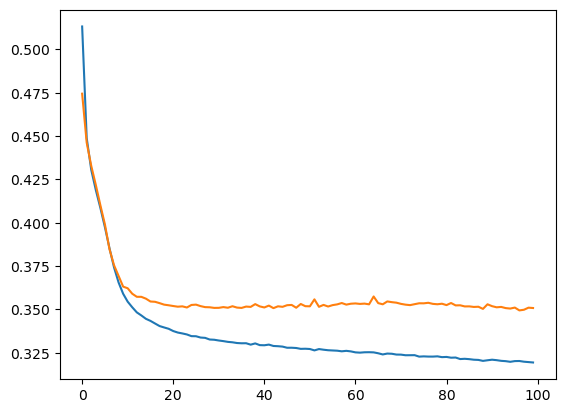

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
# plt.legend(True)



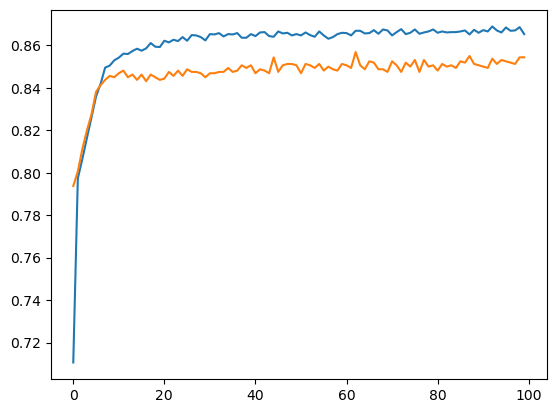

In [23]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

In [24]:
model.layers[0].get_weights()

[array([[-0.07579155,  0.09300663, -0.00664166, -0.15258414, -0.20701486,
          0.02421591, -0.0527061 , -0.03889766,  0.09242202, -0.1223482 ,
          0.19859527],
        [-0.18726717,  0.20954396, -0.16863325, -0.47836423,  0.7835617 ,
          0.20278406,  1.0561701 , -0.25991276, -0.67776644,  0.99964535,
         -0.18681365],
        [ 0.1088304 , -0.36205313,  0.27167225,  0.07609139,  0.32826948,
          0.10097264,  0.03355285,  0.09651401, -0.26181364, -0.05711878,
          0.1055647 ],
        [-0.5921902 , -0.075721  ,  0.29316378,  0.5069253 , -0.33024827,
         -0.22842343, -0.08351141, -0.5557039 , -0.39880836,  0.0795434 ,
          0.26280466],
        [ 0.4992998 ,  0.6630448 ,  1.0814805 , -0.25338453, -0.07010581,
         -1.1809098 ,  1.0329139 ,  0.03155286,  0.32510605,  0.02432781,
          0.38793626],
        [ 0.60450035, -0.11503696, -0.31442323,  0.03815019,  0.06002376,
         -0.1225816 ,  0.17941424, -0.33095846, -0.03390581,  0.0605073

In [25]:
model.layers[1].get_weights()


[array([[ 6.74284995e-01,  4.01831776e-01,  6.54924929e-01,
         -3.19321305e-02,  1.93719611e-01, -4.03442621e-01,
          3.17623645e-01,  7.17116073e-02,  2.87727892e-01,
         -2.36190885e-01,  3.52097064e-01],
        [-1.01623225e+00,  5.20296454e-01,  2.87511647e-01,
          9.33790877e-02,  3.80442828e-01,  4.26093221e-01,
         -1.50270700e-01,  4.88520175e-01,  2.82649156e-02,
          3.97925317e-01, -1.20664127e-01],
        [-9.28163901e-02,  9.32582378e-01, -8.96142889e-03,
         -4.85672772e-01,  1.85609683e-01,  4.81334627e-01,
          1.06979877e-01, -1.82819933e-01, -3.11859846e-01,
          3.82266760e-01,  6.99918211e-01],
        [ 1.75322190e-01, -1.55470297e-01,  1.79225251e-01,
          1.35937288e-01,  9.22402814e-02, -1.22307912e-01,
         -9.15372193e-01,  4.23305571e-01,  3.94261688e-01,
          3.28817844e-01, -2.77659267e-01],
        [-4.52400185e-02, -4.80054170e-01, -4.84612495e-01,
          5.87316215e-01, -5.58084011e-01,  

In [26]:
model.layers[2].get_weights()


[array([[-0.80755264],
        [ 1.1411604 ],
        [-1.1328998 ],
        [-0.6340226 ],
        [ 0.6279374 ],
        [ 0.94625634],
        [ 1.072107  ],
        [-0.40989795],
        [ 0.7647756 ],
        [ 0.7590627 ],
        [ 0.3808535 ]], dtype=float32),
 array([-0.25527847], dtype=float32)]

In [38]:
y_log = model.predict(x_test_scaled)

63/63 [==============================] - 0s 3ms/step


In [39]:
y_pred=np.where(y_log>.5,1,0)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.8615